In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:

df = pd.read_csv("online_retail.csv", encoding='ISO-8859-1')
print(df.head())
print(df.dtypes)
print(df.shape)

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER       6.0   
1    536365     71053                  WHITE METAL LANTERN       6.0   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER       8.0   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE       6.0   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.       6.0   

           InvoiceDate  UnitPrice  CustomerID         Country  
0  2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1  2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2  2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3  2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4  2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
InvoiceNo       object
StockCode       object
Description     object
Quantity       float64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object

In [25]:
missing_data = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Percentage (%)': (df.isnull().sum() / len(df)) * 100
})

print("\n--- Missing Values Summary ---")
display(missing_data)

columns_with_high_missing_percentage = missing_data[missing_data['Missing Percentage (%)'] > 20]

print("\n--- Columns with more than 20% Missing Values ---")
display(columns_with_high_missing_percentage)


--- Missing Values Summary ---


,Missing Count,Missing Percentage (%)
InvoiceNo,0,0.000000
StockCode,0,0.000000
Description,925,0.375068
Quantity,1,0.000405
InvoiceDate,1,0.000405
UnitPrice,1,0.000405
CustomerID,69155,28.040888
Country,1,0.000405



--- Columns with more than 20% Missing Values ---


,Missing Count,Missing Percentage (%)
CustomerID,69155,28.040888


In [26]:
for col in df.columns:

    if df[col].isnull().mean()*100 <20:

        if df[col].dtype!="object":

            df[col] = df[col].fillna(df[col].median())

In [27]:
duplicates = df.duplicated().sum()

print("Duplicate Rows =",duplicates)

before_null = df.isnull().sum()

df = df.drop_duplicates()

after_null = df.isnull().sum()

print("Rows after removing duplicates =",df.shape)

print("Difference in null values")

print(after_null-before_null)
print(df.dtypes)

Duplicate Rows = 2021
Rows after removing duplicates = (244601, 8)
Difference in null values
InvoiceNo       0
StockCode       0
Description     0
Quantity        0
InvoiceDate     0
UnitPrice       0
CustomerID    -26
Country         0
dtype: int64
InvoiceNo       object
StockCode       object
Description     object
Quantity       float64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object


In [28]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["CustomerID"] = pd.to_numeric(df["CustomerID"],errors="coerce")
before = df.memory_usage(deep=True).sum()

df["Country"] = df["Country"].astype("category")

after = df.memory_usage(deep=True).sum()

print("Memory Before =",before)

print("Memory After =",after)
print(df.describe())

Memory Before = 70160538
Memory After = 55143558
            Quantity                    InvoiceDate      UnitPrice  \
count  244601.000000                         244600  244601.000000   
mean        9.369622  2011-03-15 05:31:14.060752384       5.111804   
min    -74215.000000            2010-12-01 08:26:00       0.000000   
25%         1.000000            2011-01-18 13:05:00       1.250000   
50%         3.000000            2011-03-17 18:24:00       2.100000   
75%        10.000000            2011-05-11 10:32:00       4.210000   
max     74215.000000            2011-07-01 13:02:00   38970.000000   
std       221.073432                            NaN     118.894629   

          CustomerID  
count  175472.000000  
mean    15277.508030  
min     12346.000000  
25%     13842.000000  
50%     15139.000000  
75%     16814.000000  
max     18287.000000  
std      1726.009808  


In [29]:
numeric = df.select_dtypes(include=np.number)

skew = numeric.skew()

print(skew)

highest = skew.abs().idxmax()

print("Highest Skewed Column =",highest)

Quantity       -1.206894
UnitPrice     199.099376
CustomerID      0.036207
dtype: float64
Highest Skewed Column = UnitPrice


In [30]:
cols=["Quantity","UnitPrice"]

for col in cols:

    Q1=df[col].quantile(0.25)

    Q3=df[col].quantile(0.75)

    IQR=Q3-Q1

    lower=Q1-1.5*IQR

    upper=Q3+1.5*IQR

    out=((df[col]<lower)|(df[col]>upper)).sum()

    print(col,out)

Quantity 25742
UnitPrice 16777


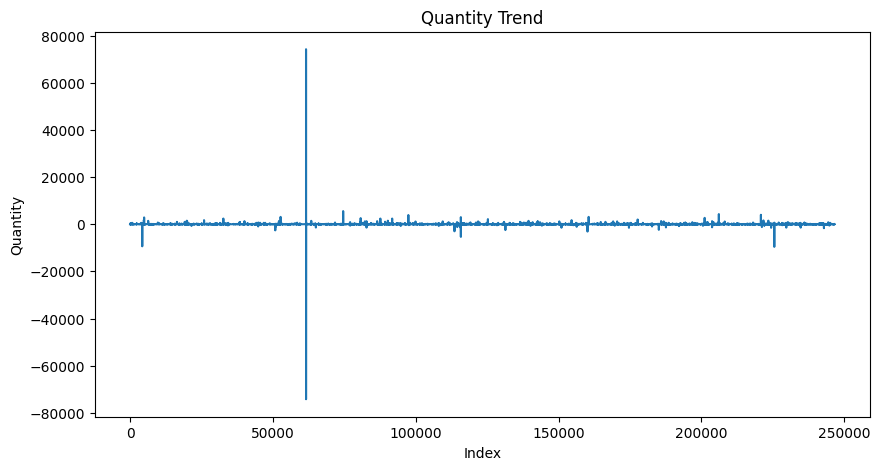

In [31]:
plt.figure(figsize=(10,5))

plt.plot(df.index,df["Quantity"])

plt.title("Quantity Trend")

plt.xlabel("Index")

plt.ylabel("Quantity")

plt.show()

/tmp/ipykernel_728/3767256548.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  country_mean=df.groupby("Country")["Quantity"].mean().sort_values(ascending=False).head(10)


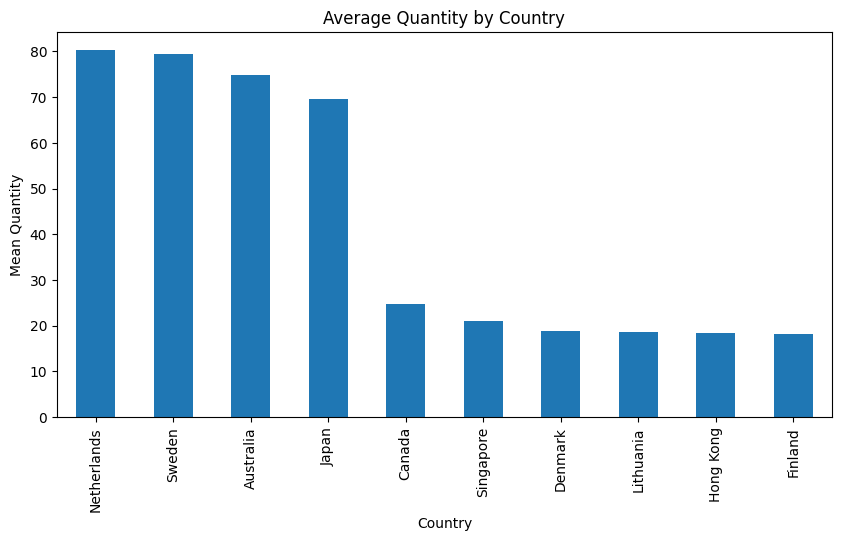

In [32]:
country_mean=df.groupby("Country")["Quantity"].mean().sort_values(ascending=False).head(10)

country_mean.plot.bar(figsize=(10,5))

plt.title("Average Quantity by Country")

plt.xlabel("Country")

plt.ylabel("Mean Quantity")

plt.show()

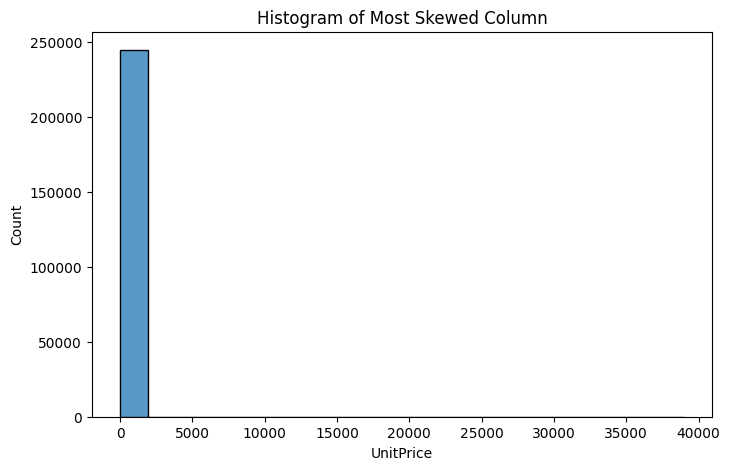

In [33]:
plt.figure(figsize=(8,5))

sns.histplot(df[highest],bins=20)

plt.title("Histogram of Most Skewed Column")

plt.show()

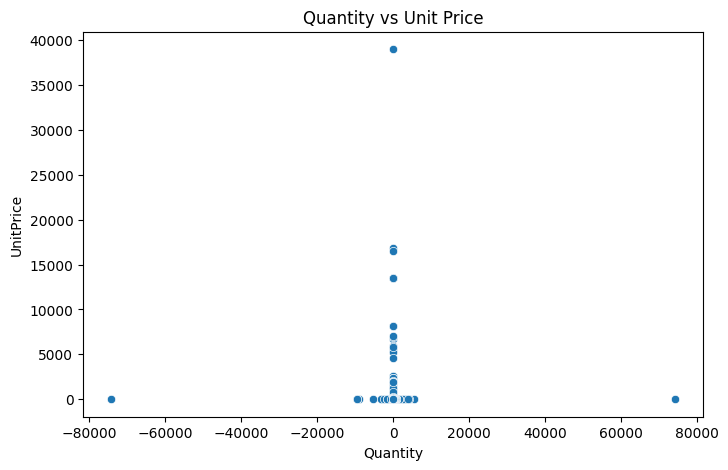

In [34]:
plt.figure(figsize=(8,5))

sns.scatterplot(data=df,x="Quantity",y="UnitPrice")

plt.title("Quantity vs Unit Price")

plt.show()

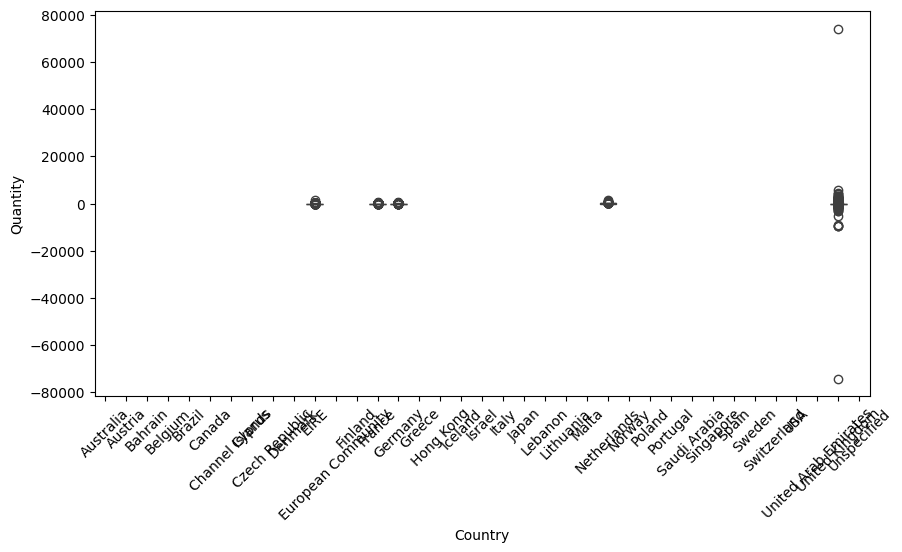

In [35]:
top=df[df["Country"].isin(df["Country"].value_counts().head(5).index)]

plt.figure(figsize=(10,5))

sns.boxplot(data=top,x="Country",y="Quantity")

plt.xticks(rotation=45)

plt.show()

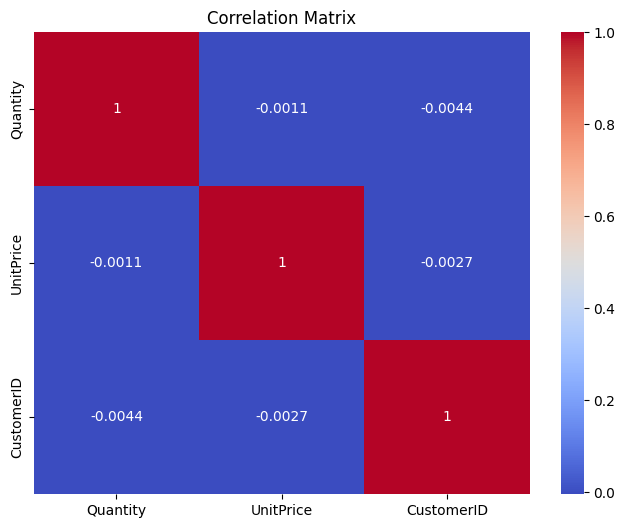

In [36]:
corr=df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(8,6))

sns.heatmap(corr,annot=True,cmap="coolwarm")

plt.title("Correlation Matrix")

plt.show()

In [37]:
corr_matrix=corr.abs()

np.fill_diagonal(corr_matrix.values,0)

pair=np.unravel_index(corr_matrix.values.argmax(),corr_matrix.shape)

print(corr_matrix.index[pair[0]],corr_matrix.columns[pair[1]])

Quantity CustomerID


In [38]:
top2=skew.abs().sort_values(ascending=False).head(2).index

for col in top2:

    print(col)

    print("Mean =",df[col].mean())

    print("Median =",df[col].median())

    df[col]=df[col].fillna(df[col].median())

    print(df[col].isnull().sum())

UnitPrice
Mean = 5.111803512659392
Median = 2.1
0
Quantity
Mean = 9.36962236458559
Median = 3.0
0


In [39]:
pearson=df.select_dtypes(include=np.number).corr()

spearman=df.select_dtypes(include=np.number).corr(method="spearman")

print(pearson)

print(spearman)

difference=(spearman-pearson).abs()

print(difference)

            Quantity  UnitPrice  CustomerID
Quantity    1.000000  -0.001138   -0.004410
UnitPrice  -0.001138   1.000000   -0.002672
CustomerID -0.004410  -0.002672    1.000000
            Quantity  UnitPrice  CustomerID
Quantity    1.000000  -0.409236   -0.154048
UnitPrice  -0.409236   1.000000    0.000366
CustomerID -0.154048   0.000366    1.000000
            Quantity  UnitPrice  CustomerID
Quantity    0.000000   0.408098    0.149638
UnitPrice   0.408098   0.000000    0.003037
CustomerID  0.149638   0.003037    0.000000


In [40]:
pairs=[]

for i in difference.columns:

    for j in difference.columns:

        if i<j:

            pairs.append([i,j,difference.loc[i,j]])

pairs=pd.DataFrame(pairs,columns=["Column1","Column2","Difference"])

print(pairs.sort_values("Difference",ascending=False).head(3))

      Column1    Column2  Difference
0    Quantity  UnitPrice    0.408098
1  CustomerID   Quantity    0.149638
2  CustomerID  UnitPrice    0.003037


In [41]:
group=df.groupby("Country")["Quantity"].agg(["mean","std","count"])

print(group)

highest_mean=group["mean"].idxmax()

highest_std=group["std"].idxmax()

ratio=group["mean"].max()/group["mean"].min()

print(highest_mean)

print(highest_std)

print(ratio)

                           mean         std   count
Country                                            
Australia             74.871833   92.705834     671
Austria               16.598425   37.127036     127
Bahrain               13.684211   30.016759      19
Belgium               11.284958   13.232578     944
Brazil                11.125000    8.476723      32
Canada                24.764706   68.463983      68
Channel Islands       12.304348   23.751433     368
Cyprus                13.088068   29.426051     352
Czech Republic        18.058824   17.199094      17
Denmark               18.853261   20.023898     184
EIRE                  16.724468   41.432970    3241
European Community     5.062500    3.950806      32
Finland               18.073718   25.963944     312
France                13.536374   20.719453    3684
Germany               12.497069   18.884600    4265
Greece                12.670588    8.684124      85
Hong Kong             18.326531   18.760720     196
Iceland     

/tmp/ipykernel_728/2987799318.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group=df.groupby("Country")["Quantity"].agg(["mean","std","count"])


In [42]:
df.to_csv("cleaned_data.csv",index=False)

print("Dataset Saved Successfully")

Dataset Saved Successfully


In [ ]:
import pandas as pd
df_cleaned = pd.read_csv('cleaned_data.csv')
df_cleaned['InvoiceDate'] = pd.to_datetime(df_cleaned['InvoiceDate'])
y_reg = df_cleaned['UnitPrice']
median_unit_price = y_reg.median()
y_clf = (y_reg > median_unit_price).astype(int)
X = df_cleaned.drop(columns=['UnitPrice'])
print(f"Shape of X: {X.shape}")
print(f"Shape of y_reg: {y_reg.shape}")
print(f"Shape of y_clf: {y_clf.shape}")
print("\nX head:")
display(X.head())
print("\ny_reg head:")
display(y_reg.head())
print("\ny_clf head:")
display(y_clf.head())

Shape of X: (244601, 7)
Shape of y_reg: (244601,)
Shape of y_clf: (244601,)

X head:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6.0,2010-12-01 08:26:00,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6.0,2010-12-01 08:26:00,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8.0,2010-12-01 08:26:00,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6.0,2010-12-01 08:26:00,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6.0,2010-12-01 08:26:00,17850.0,United Kingdom



y_reg head:


,UnitPrice
0,2.55
1,3.39
2,2.75
3,3.39
4,3.39



y_clf head:


,UnitPrice
0,1
1,1
2,1
3,1
4,1


In [ ]:

columns_to_drop = ['InvoiceNo', 'StockCode', 'Description']
X_processed = X.drop(columns=columns_to_drop, errors='ignore')
X_processed['InvoiceYear'] = X_processed['InvoiceDate'].dt.year
X_processed['InvoiceMonth'] = X_processed['InvoiceDate'].dt.month
X_processed['InvoiceDay'] = X_processed['InvoiceDate'].dt.day
X_processed['InvoiceDayOfWeek'] = X_processed['InvoiceDate'].dt.dayofweek
X_processed['InvoiceHour'] = X_processed['InvoiceDate'].dt.hour
X_processed = X_processed.drop(columns=['InvoiceDate'])
categorical_cols = X_processed.select_dtypes(include=['object', 'category']).columns
print("Categorical columns in X_processed before encoding:")
print(categorical_cols)
X_encoded = pd.get_dummies(X_processed, columns=categorical_cols, drop_first=True, dummy_na=False)
print(f"\nShape of X after feature engineering and one-hot encoding: {X_encoded.shape}")
print("\nFirst 5 rows of X after feature engineering and one-hot encoding:")
display(X_encoded.head())

Categorical columns in X_processed before encoding:
Index(['Country'], dtype='object')

Shape of X after feature engineering and one-hot encoding: (244601, 43)

First 5 rows of X after feature engineering and one-hot encoding:


,Quantity,CustomerID,InvoiceYear,InvoiceMonth,InvoiceDay,InvoiceDayOfWeek,InvoiceHour,Country_Austria,Country_Bahrain,Country_Belgium,...,Country_Portugal,Country_Saudi Arabia,Country_Singapore,Country_Spain,Country_Sweden,Country_Switzerland,Country_USA,Country_United Arab Emirates,Country_United Kingdom,Country_Unspecified
0,6.0,17850.0,2010.0,12.0,1.0,2.0,8.0,False,False,False,...,False,False,False,False,False,False,False,False,True,False
1,6.0,17850.0,2010.0,12.0,1.0,2.0,8.0,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,8.0,17850.0,2010.0,12.0,1.0,2.0,8.0,False,False,False,...,False,False,False,False,False,False,False,False,True,False
3,6.0,17850.0,2010.0,12.0,1.0,2.0,8.0,False,False,False,...,False,False,False,False,False,False,False,False,True,False
4,6.0,17850.0,2010.0,12.0,1.0,2.0,8.0,False,False,False,...,False,False,False,False,False,False,False,False,True,False


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
if 'CustomerID' in X_encoded.columns:
    customer_id_median = X_encoded['CustomerID'].median()
    X_encoded['CustomerID'] = X_encoded['CustomerID'].fillna(customer_id_median)
X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test = train_test_split(
    X_encoded, y_reg, y_clf, test_size=0.2, random_state=42
)
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Shapes after train-test split and scaling:")
print(f"X_train_scaled: {X_train_scaled.shape}")
print(f"X_test_scaled: {X_test_scaled.shape}")
print(f"y_reg_train: {y_reg_train.shape}")
print(f"y_reg_test: {y_reg_test.shape}")
print(f"y_clf_train: {y_clf_train.shape}")
print(f"y_clf_test: {y_clf_test.shape}")
print("\nFirst 5 rows of X_train_scaled (as DataFrame for display): ")
display(pd.DataFrame(X_train_scaled, columns=X_encoded.columns).head())

Shapes after train-test split and scaling:
X_train_scaled: (195680, 43)
X_test_scaled: (48921, 43)
y_reg_train: (195680,)
y_reg_test: (48921,)
y_clf_train: (195680,)
y_clf_test: (48921,)

First 5 rows of X_train_scaled (as DataFrame for display): 


,Quantity,CustomerID,InvoiceYear,InvoiceMonth,InvoiceDay,InvoiceDayOfWeek,InvoiceHour,Country_Austria,Country_Bahrain,Country_Belgium,...,Country_Portugal,Country_Saudi Arabia,Country_Singapore,Country_Spain,Country_Sweden,Country_Switzerland,Country_USA,Country_United Arab Emirates,Country_United Kingdom,Country_Unspecified
0,-0.030149,-0.069177,0.456266,-0.009431,1.971203,-0.757035,0.790371,-0.022837,-0.006782,-0.061821,...,-0.050155,-0.005981,-0.021688,-0.068767,-0.028337,-0.05518,-0.009591,-0.010842,0.299625,-0.018781
1,-0.030149,1.623158,0.456266,-0.290966,-1.637342,0.905619,-1.627939,-0.022837,-0.006782,-0.061821,...,-0.050155,-0.005981,-0.021688,-0.068767,-0.028337,-0.05518,-0.009591,-0.010842,0.299625,-0.018781
2,-0.034233,1.779120,0.456266,-0.854035,1.610348,-1.311253,0.790371,-0.022837,-0.006782,-0.061821,...,-0.050155,-0.005981,-0.021688,-0.068767,-0.028337,-0.05518,-0.009591,-0.010842,0.299625,-0.018781
3,-0.034233,-1.375024,0.456266,-0.854035,-1.396772,0.351401,2.402578,-0.022837,-0.006782,-0.061821,...,-0.050155,-0.005981,-0.021688,-0.068767,-0.028337,-0.05518,-0.009591,-0.010842,0.299625,-0.018781
4,-0.034233,-0.069177,0.456266,0.272103,1.610348,-0.757035,-0.821836,-0.022837,-0.006782,-0.061821,...,-0.050155,-0.005981,-0.021688,-0.068767,-0.028337,-0.05518,-0.009591,-0.010842,0.299625,-0.018781


In [ ]:
import numpy as np
print("NaNs in X_train_scaled:", np.isnan(X_train_scaled).sum())
print("NaNs in X_test_scaled:", np.isnan(X_test_scaled).sum())

NaNs in X_train_scaled: 5
NaNs in X_test_scaled: 0


In [ ]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.impute import SimpleImputer
import numpy as np
imputer = SimpleImputer(strategy='median')
X_train_scaled_imputed = imputer.fit_transform(X_train_scaled)
X_test_scaled_imputed = imputer.transform(X_test_scaled)
print("\n--- Linear Regression ---")
linear_model = LinearRegression()
linear_model.fit(X_train_scaled_imputed, y_reg_train)
y_pred_reg = linear_model.predict(X_test_scaled_imputed)
mse_linear = mean_squared_error(y_reg_test, y_pred_reg)
r2_linear = r2_score(y_reg_test, y_pred_reg)
print(f"Mean Squared Error (Linear Regression): {mse_linear:.4f}")
print(f"R-squared (Linear Regression): {r2_linear:.4f}")
print("\nLinear Regression Coefficients:")
coefficients = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Coefficient': linear_model.coef_
})
display(coefficients.sort_values(by='Coefficient', ascending=False))
coefficients['Abs_Coefficient'] = np.abs(coefficients['Coefficient'])
top_3_features = coefficients.sort_values(by='Abs_Coefficient', ascending=False).head(3)
print("\nTop 3 features with largest absolute coefficients:")
display(top_3_features[['Feature', 'Coefficient']])
print("\n--- Ridge Regression ---")
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled_imputed, y_reg_train)
y_pred_ridge = ridge_model.predict(X_test_scaled_imputed)

mse_ridge = mean_squared_error(y_reg_test, y_pred_ridge)
r2_ridge = r2_score(y_reg_test, y_pred_ridge)

print(f"Mean Squared Error (Ridge Regression): {mse_ridge:.4f}")
print(f"R-squared (Ridge Regression): {r2_ridge:.4f}")


--- Linear Regression ---
Mean Squared Error (Linear Regression): 3980.1822
R-squared (Linear Regression): 0.0012

Linear Regression Coefficients:


,Feature,Coefficient
35,Country_Singapore,2.277516
22,Country_Hong Kong,0.945180
41,Country_United Kingdom,0.803738
16,Country_EIRE,0.593806
33,Country_Portugal,0.500019
3,InvoiceMonth,0.448674
31,Country_Norway,0.282759
6,InvoiceHour,0.272387
36,Country_Spain,0.194954
19,Country_France,0.186382



Top 3 features with largest absolute coefficients:


,Feature,Coefficient
35,Country_Singapore,2.277516
22,Country_Hong Kong,0.945180
41,Country_United Kingdom,0.803738



--- Ridge Regression ---
Mean Squared Error (Ridge Regression): 3980.1821
R-squared (Ridge Regression): 0.0012


The class distribution of `y_clf_train` is as follows:

*   **Class 0:** 179,917 samples (45.13%)
*   **Class 1:** 218,683 samples (54.87%)

Since neither class has fewer than 35% of the samples, I will proceed *without* applying any explicit class imbalance handling techniques (such as SMOTE or `class_weight='balanced'`).

TRAIN LOGISTIC REGRESSION MODEL 


--- Logistic Regression Model (C=1.0, baseline) ---

Confusion Matrix:


,Predicted 0,Predicted 1
Actual 0,14616,10237
Actual 1,8806,15262



Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.59      0.61     24853
           1       0.60      0.63      0.62     24068

    accuracy                           0.61     48921
   macro avg       0.61      0.61      0.61     48921
weighted avg       0.61      0.61      0.61     48921



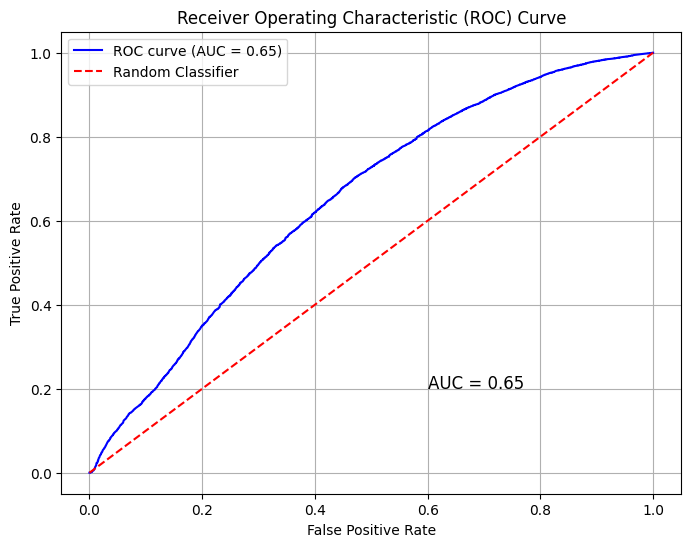


Area Under the Curve (AUC): 0.6511


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score
import matplotlib.pyplot as plt
print("\n--- Logistic Regression Model (C=1.0, baseline) ---")
log_reg_model = LogisticRegression(max_iter=1000, random_state=42, C=1.0) # C=1.0 is default
log_reg_model.fit(X_train_scaled_imputed, y_clf_train)
y_pred_clf = log_reg_model.predict(X_test_scaled_imputed)
y_proba_clf = log_reg_model.predict_proba(X_test_scaled_imputed)[:, 1]
print("\nConfusion Matrix:")
display(pd.DataFrame(confusion_matrix(y_clf_test, y_pred_clf), index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1']))

print("\nClassification Report:")
print(classification_report(y_clf_test, y_pred_clf))
fpr, tpr, thresholds = roc_curve(y_clf_test, y_proba_clf)
auc_score = roc_auc_score(y_clf_test, y_proba_clf)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.annotate(f'AUC = {auc_score:.2f}', xy=(0.6, 0.2), xytext=(0.6, 0.2), fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

print(f"\nArea Under the Curve (AUC): {auc_score:.4f}")

DECISION-THRESHOLD SENSITIVITY


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score
probabilities = log_reg_model.predict_proba(X_test_scaled)[:, 1]
thresholds = np.arange(0.30, 0.71, 0.10)

results = []
for threshold in thresholds:
    y_pred_threshold = (probabilities >= threshold).astype(int)
    precision = precision_score(y_clf_test, y_pred_threshold)
    recall = recall_score(y_clf_test, y_pred_threshold)
    f1 = f1_score(y_clf_test, y_pred_threshold)

    results.append({'Threshold': f'{threshold:.2f}', 'Precision': f'{precision:.4f}', 'Recall': f'{recall:.4f}', 'F1-Score': f'{f1:.4f}'})
print("\nDecision Threshold Sensitivity Analysis:")
display(pd.DataFrame(results))



Decision Threshold Sensitivity Analysis:


,Threshold,Precision,Recall,F1-Score
0,0.30,0.5001,0.9929,0.6652
1,0.40,0.5178,0.9729,0.6759
2,0.50,0.5985,0.6341,0.6158
3,0.60,0.6858,0.0551,0.1019
4,0.70,0.2661,0.0012,0.0024


 REGULARIZATION ON LOGISTIC REGRESSION


In [ ]:

print("\n--- Logistic Regression Model (C=0.01, strong regularization) ---")
log_reg_model_C001 = LogisticRegression(max_iter=1000, random_state=42, C=0.01)
log_reg_model_C001.fit(X_train_scaled_imputed, y_clf_train)
y_pred_clf_C001 = log_reg_model_C001.predict(X_test_scaled_imputed)
y_proba_clf_C001 = log_reg_model_C001.predict_proba(X_test_scaled_imputed)[:, 1]
report_C001 = classification_report(y_clf_test, y_pred_clf_C001, output_dict=True)
auc_score_C001 = roc_auc_score(y_clf_test, y_proba_clf_C001)

print("\nClassification Report (C=0.01):")
print(classification_report(y_clf_test, y_pred_clf_C001))
print(f"\nArea Under the Curve (AUC) (C=0.01): {auc_score_C001:.4f}")
report_baseline = classification_report(y_clf_test, y_pred_clf, output_dict=True)
auc_score_baseline = auc_score

comparison_data = {
    'Model': ['Logistic Regression (C=1.0)', 'Logistic Regression (C=0.01)'],
    'Precision (Class 1)': [report_baseline['1']['precision'], report_C001['1']['precision']],
    'Recall (Class 1)': [report_baseline['1']['recall'], report_C001['1']['recall']],
    'AUC': [auc_score_baseline, auc_score_C001]
}

print("\nComparison of Logistic Regression Models (C=1.0 vs C=0.01):")
display(pd.DataFrame(comparison_data))


--- Logistic Regression Model (C=0.01, strong regularization) ---

Classification Report (C=0.01):
              precision    recall  f1-score   support

           0       0.60      0.59      0.59     24853
           1       0.58      0.59      0.59     24068

    accuracy                           0.59     48921
   macro avg       0.59      0.59      0.59     48921
weighted avg       0.59      0.59      0.59     48921


Area Under the Curve (AUC) (C=0.01): 0.6271

Comparison of Logistic Regression Models (C=1.0 vs C=0.01):


,Model,Precision (Class 1),Recall (Class 1),AUC
0,Logistic Regression (C=1.0),0.598533,0.634120,0.651060
1,Logistic Regression (C=0.01),0.582806,0.588956,0.627064


 BOOTSTRAP CONFIDENCE INTERVAL


In [ ]:
from sklearn.metrics import roc_auc_score
import numpy as np

n_iterations = 500
auc_differences = []
n_test_samples = len(y_clf_test)

for i in range(n_iterations):
    bootstrap_indices = np.random.choice(n_test_samples, size=n_test_samples, replace=True)
    y_true_bootstrap = y_clf_test.iloc[bootstrap_indices]
    y_proba_clf_bootstrap = y_proba_clf[bootstrap_indices]
    y_proba_clf_C001_bootstrap = y_proba_clf_C001[bootstrap_indices]
    auc_c1_0_bootstrap = roc_auc_score(y_true_bootstrap, y_proba_clf_bootstrap)
    auc_c0_01_bootstrap = roc_auc_score(y_true_bootstrap, y_proba_clf_C001_bootstrap)
    auc_differences.append(auc_c1_0_bootstrap - auc_c0_01_bootstrap)
auc_differences = np.array(auc_differences)
mean_auc_difference = np.mean(auc_differences)
lower_bound = np.percentile(auc_differences, 2.5)
upper_bound = np.percentile(auc_differences, 97.5)
print(f"Mean AUC difference (C=1.0 - C=0.01): {mean_auc_difference:.4f}")
print(f"95% Confidence Interval for AUC difference: [{lower_bound:.4f}, {upper_bound:.4f}]")
if lower_bound <= 0 <= upper_bound:
    print("The 95% confidence interval includes zero. The difference in AUC may not be statistically reliable.")
else:
    print("The 95% confidence interval does NOT include zero. The C=1.0 model's advantage is likely consistent across different data samples.")

Mean AUC difference (C=1.0 - C=0.01): 0.0240
95% Confidence Interval for AUC difference: [0.0231, 0.0247]
The 95% confidence interval does NOT include zero. The C=1.0 model's advantage is likely consistent across different data samples.


DECISION TREE CLASSIFIER

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
print("\n--- Decision Tree Classifier Baseline ---")
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_scaled, y_clf_train)
y_train_pred_dt = dt_model.predict(X_train_scaled)
y_test_pred_dt = dt_model.predict(X_test_scaled)
train_accuracy_dt = accuracy_score(y_clf_train, y_train_pred_dt)
test_accuracy_dt = accuracy_score(y_clf_test, y_test_pred_dt)
print(f"Training Accuracy (Decision Tree): {train_accuracy_dt:.4f}")
print(f"Test Accuracy (Decision Tree): {test_accuracy_dt:.4f}")


--- Decision Tree Classifier Baseline ---
Training Accuracy (Decision Tree): 0.8368
Test Accuracy (Decision Tree): 0.7610


CONTROLLED DECISION TREE

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
print("\n--- Controlled Decision Tree Classifier ---")
dt_controlled_model = DecisionTreeClassifier(max_depth=5, min_samples_split=20, random_state=42)
dt_controlled_model.fit(X_train_scaled, y_clf_train)
y_train_pred_dt_controlled = dt_controlled_model.predict(X_train_scaled)
y_test_pred_dt_controlled = dt_controlled_model.predict(X_test_scaled)
train_accuracy_dt_controlled = accuracy_score(y_clf_train, y_train_pred_dt_controlled)
test_accuracy_dt_controlled = accuracy_score(y_clf_test, y_test_pred_dt_controlled)
print(f"Training Accuracy (Controlled Decision Tree): {train_accuracy_dt_controlled:.4f}")
print(f"Test Accuracy (Controlled Decision Tree): {test_accuracy_dt_controlled:.4f}")


--- Controlled Decision Tree Classifier ---
Training Accuracy (Controlled Decision Tree): 0.7000
Test Accuracy (Controlled Decision Tree): 0.7011


GINI MODEL

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
print("\n--- Decision Tree Classifier (Criterion: Gini) ---")
dt_gini_model = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=42)
dt_gini_model.fit(X_train_scaled, y_clf_train)
y_test_pred_dt_gini = dt_gini_model.predict(X_test_scaled)
test_accuracy_dt_gini = accuracy_score(y_clf_test, y_test_pred_dt_gini)
print(f"Test Accuracy (Decision Tree - Gini): {test_accuracy_dt_gini:.4f}")
print("\n--- Decision Tree Classifier (Criterion: Entropy) ---")
dt_entropy_model = DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)
dt_entropy_model.fit(X_train_scaled, y_clf_train)
y_test_pred_dt_entropy = dt_entropy_model.predict(X_test_scaled)
test_accuracy_dt_entropy = accuracy_score(y_clf_test, y_test_pred_dt_entropy)
print(f"Test Accuracy (Decision Tree - Entropy): {test_accuracy_dt_entropy:.4f}")


--- Decision Tree Classifier (Criterion: Gini) ---
Test Accuracy (Decision Tree - Gini): 0.7011

--- Decision Tree Classifier (Criterion: Entropy) ---
Test Accuracy (Decision Tree - Entropy): 0.7012


RANDOM FOREST CLASSIFIER

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
print("\n--- Random Forest Classifier ---")
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train_scaled, y_clf_train)
y_train_pred_rf = rf_model.predict(X_train_scaled)
y_test_pred_rf = rf_model.predict(X_test_scaled)
y_proba_rf = rf_model.predict_proba(X_test_scaled)[:, 1]
train_accuracy_rf = accuracy_score(y_clf_train, y_train_pred_rf)
test_accuracy_rf = accuracy_score(y_clf_test, y_test_pred_rf)
roc_auc_rf = roc_auc_score(y_clf_test, y_proba_rf)

print(f"Training Accuracy (Random Forest): {train_accuracy_rf:.4f}")
print(f"Test Accuracy (Random Forest): {test_accuracy_rf:.4f}")
print(f"ROC-AUC (Random Forest): {roc_auc_rf:.4f}")
feature_importances = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Importance': rf_model.feature_importances_
})

top_5_features = feature_importances.sort_values(by='Importance', ascending=False).head(5)
print("\nTop 5 Features by Importance:")
display(top_5_features)


--- Random Forest Classifier ---
Training Accuracy (Random Forest): 0.7146
Test Accuracy (Random Forest): 0.7118
ROC-AUC (Random Forest): 0.7879

Top 5 Features by Importance:


,Feature,Importance
0,Quantity,0.723156
1,CustomerID,0.137551
6,InvoiceHour,0.049904
5,InvoiceDayOfWeek,0.024155
3,InvoiceMonth,0.018974


GRADIENT BOOSTING CLASSIFIER

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
print("\n--- Gradient Boosting Classifier ---")
gbc_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gbc_model.fit(X_train_scaled_imputed, y_clf_train)
y_train_pred_gbc = gbc_model.predict(X_train_scaled_imputed)
y_test_pred_gbc = gbc_model.predict(X_test_scaled_imputed)
y_proba_gbc = gbc_model.predict_proba(X_test_scaled_imputed)[:, 1]
train_accuracy_gbc = accuracy_score(y_clf_train, y_train_pred_gbc)
test_accuracy_gbc = accuracy_score(y_clf_test, y_test_pred_gbc)
roc_auc_gbc = roc_auc_score(y_clf_test, y_proba_gbc)
print(f"Training Accuracy (Gradient Boosting): {train_accuracy_gbc:.4f}")
print(f"Test Accuracy (Gradient Boosting): {test_accuracy_gbc:.4f}")
print(f"ROC-AUC (Gradient Boosting): {roc_auc_gbc:.4f}")


--- Gradient Boosting Classifier ---
Training Accuracy (Gradient Boosting): 0.7168
Test Accuracy (Gradient Boosting): 0.7152
ROC-AUC (Gradient Boosting): 0.7879


FEATURE ABLATION

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
import pandas as pd
lowest_5_features = feature_importances.sort_values(by='Importance', ascending=True).head(5)
features_to_remove = lowest_5_features['Feature'].tolist()
print(f"\nFeatures to remove (lowest 5 importance scores): {features_to_remove}")
all_features = X_encoded.columns.tolist()
indices_to_remove = [all_features.index(f) for f in features_to_remove]
X_train_df = pd.DataFrame(X_train_scaled, columns=all_features)
X_test_df = pd.DataFrame(X_test_scaled, columns=all_features)

X_train_scaled_reduced = X_train_df.drop(columns=features_to_remove).values
X_test_scaled_reduced = X_test_df.drop(columns=features_to_remove).values

print(f"Shape of X_train_scaled_reduced: {X_train_scaled_reduced.shape}")
print(f"Shape of X_test_scaled_reduced: {X_test_scaled_reduced.shape}")
print("\n--- Random Forest Classifier (Reduced Features) ---")
rf_model_reduced = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_model_reduced.fit(X_train_scaled_reduced, y_clf_train)
y_proba_rf_reduced = rf_model_reduced.predict_proba(X_test_scaled_reduced)[:, 1]
roc_auc_rf_reduced = roc_auc_score(y_clf_test, y_proba_rf_reduced)

print(f"ROC-AUC (Full Random Forest Model): {roc_auc_rf:.4f}")
print(f"ROC-AUC (Reduced Random Forest Model): {roc_auc_rf_reduced:.4f}")


Features to remove (lowest 5 importance scores): ['Country_Saudi Arabia', 'Country_USA', 'Country_Malta', 'Country_United Arab Emirates', 'Country_Poland']
Shape of X_train_scaled_reduced: (195680, 38)
Shape of X_test_scaled_reduced: (48921, 38)

--- Random Forest Classifier (Reduced Features) ---
ROC-AUC (Full Random Forest Model): 0.7879
ROC-AUC (Reduced Random Forest Model): 0.7912


### Hyperparameter Tuning with GridSearchCV

In [ ]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
param_grid = {
    'randomforestclassifier__n_estimators': [50, 100, 200],
    'randomforestclassifier__max_depth': [5, 10, None],
    'randomforestclassifier__min_samples_leaf': [1, 5]
}
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('randomforestclassifier', RandomForestClassifier(random_state=42))
])
skf_grid = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print("\n--- Running GridSearchCV for RandomForestClassifier ---")
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=skf_grid,
    scoring='roc_auc',
    n_jobs=-1,  # Use all available CPU cores
    verbose=2
)
grid_search.fit(X_encoded, y_clf)
print("\nBest parameters found:", grid_search.best_params_)
print("Best ROC-AUC score:", grid_search.best_score_)
best_rf_model = grid_search.best_estimator_
num_n_estimators = len(param_grid['randomforestclassifier__n_estimators'])
num_max_depth = len(param_grid['randomforestclassifier__max_depth'])
num_min_samples_leaf = len(param_grid['randomforestclassifier__min_samples_leaf'])
num_folds = skf_grid.get_n_splits()

total_configurations = num_n_estimators * num_max_depth * num_min_samples_leaf * num_folds
print(f"Total model configurations evaluated: {total_configurations}")


--- Running GridSearchCV for RandomForestClassifier ---
Fitting 5 folds for each of 18 candidates, totalling 90 fits

Best parameters found: {'randomforestclassifier__max_depth': None, 'randomforestclassifier__min_samples_leaf': 1, 'randomforestclassifier__n_estimators': 200}
Best ROC-AUC score: 0.8506866330259377
Total model configurations evaluated: 90


SERIALIZATION

In [ ]:
import joblib
import pandas as pd
import numpy as np
joblib.dump(best_rf_model, 'best_model.pkl')
print("Best model pipeline saved as 'best_model.pkl'")
loaded_model = joblib.load('best_model.pkl')
print("Model loaded successfully.")
feature_names = X_encoded.columns.tolist()
test_row_1_data = X_encoded.iloc[0].copy()
test_row_1_data['Quantity'] = 50 # High quantity
test_row_1_data['CustomerID'] = 17850.0 # Same customer
test_row_1_data['InvoiceMonth'] = 11 # Later month
test_row_1_data['InvoiceDay'] = 25 # Later day
test_row_2_data = X_encoded.iloc[100].copy()
test_row_2_data['Quantity'] = 1 # Low quantity
test_row_2_data['CustomerID'] = 12347.0 # Different customer
test_row_2_data['InvoiceMonth'] = 1 # Earlier month
test_row_2_data['InvoiceDay'] = 5 # Earlier day
hand_crafted_test_data = pd.DataFrame([test_row_1_data, test_row_2_data], columns=feature_names)

print("\nHand-crafted test data for prediction:")
display(hand_crafted_test_data)
predictions = loaded_model.predict(hand_crafted_test_data)
probabilities = loaded_model.predict_proba(hand_crafted_test_data)[:, 1]
print("\nPredictions (0 = UnitPrice <= median, 1 = UnitPrice > median):")
print(f"Test Row 1 Prediction: {predictions[0]} (Probability of 1: {probabilities[0]:.4f})")
print(f"Test Row 2 Prediction: {predictions[1]} (Probability of 1: {probabilities[1]:.4f})")

Best model pipeline saved as 'best_model.pkl'
Model loaded successfully.

Hand-crafted test data for prediction:


,Quantity,CustomerID,InvoiceYear,InvoiceMonth,InvoiceDay,InvoiceDayOfWeek,InvoiceHour,Country_Austria,Country_Bahrain,Country_Belgium,...,Country_Portugal,Country_Saudi Arabia,Country_Singapore,Country_Spain,Country_Sweden,Country_Switzerland,Country_USA,Country_United Arab Emirates,Country_United Kingdom,Country_Unspecified
0,50,17850.0,2010.0,11,25,2.0,8.0,False,False,False,...,False,False,False,False,False,False,False,False,True,False
100,1,12347.0,2010.0,1,5,2.0,9.0,False,False,False,...,False,False,False,False,False,False,False,False,True,False



Predictions (0 = UnitPrice <= median, 1 = UnitPrice > median):
Test Row 1 Prediction: 0 (Probability of 1: 0.2188)
Test Row 2 Prediction: 1 (Probability of 1: 0.8601)


In [ ]:

y_proba_dt_baseline = dt_model.predict_proba(X_test_scaled_imputed)[:, 1]
roc_auc_dt_baseline = roc_auc_score(y_clf_test, y_proba_dt_baseline)
print(f"Test ROC-AUC (Decision Tree Baseline): {roc_auc_dt_baseline:.4f}")
y_proba_dt_controlled = dt_controlled_model.predict_proba(X_test_scaled_imputed)[:, 1]
roc_auc_dt_controlled = roc_auc_score(y_clf_test, y_proba_dt_controlled)
print(f"Test ROC-AUC (Controlled Decision Tree): {roc_auc_dt_controlled:.4f}")
y_proba_dt_gini = dt_gini_model.predict_proba(X_test_scaled_imputed)[:, 1]
roc_auc_dt_gini = roc_auc_score(y_clf_test, y_proba_dt_gini)
print(f"Test ROC-AUC (Decision Tree Gini): {roc_auc_dt_gini:.4f}")
y_proba_dt_entropy = dt_entropy_model.predict_proba(X_test_scaled_imputed)[:, 1]
roc_auc_dt_entropy = roc_auc_score(y_clf_test, y_proba_dt_entropy)
print(f"Test ROC-AUC (Decision Tree Entropy): {roc_auc_dt_entropy:.4f}")
y_proba_rf_recalc = rf_model.predict_proba(X_test_scaled_imputed)[:, 1]
roc_auc_rf_recalc = roc_auc_score(y_clf_test, y_proba_rf_recalc)
print(f"Test ROC-AUC (Random Forest Original, recalculated): {roc_auc_rf_recalc:.4f}")
y_proba_best_rf = best_rf_model.predict_proba(X_test)[:, 1] 
roc_auc_best_rf = roc_auc_score(y_clf_test, y_proba_best_rf)
print(f"Test ROC-AUC (Tuned Random Forest): {roc_auc_best_rf:.4f}")
test_auc_scores = {
    'Logistic Regression (C=1.0)': auc_score,
    'Logistic Regression (C=0.01)': auc_score_C001,
    'Decision Tree Baseline': roc_auc_dt_baseline,
    'Controlled Decision Tree': roc_auc_dt_controlled,
    'Decision Tree Gini': roc_auc_dt_gini,
    'Decision Tree Entropy': roc_auc_dt_entropy,
    'Random Forest Classifier': roc_auc_rf_recalc, 
    'Gradient Boosting Classifier': roc_auc_gbc,
    'Random Forest Classifier (Reduced Features)': roc_auc_rf_reduced,
    'Tuned Random Forest (GridSearchCV)': roc_auc_best_rf
}

Test ROC-AUC (Decision Tree Baseline): 0.8204
Test ROC-AUC (Controlled Decision Tree): 0.7616
Test ROC-AUC (Decision Tree Gini): 0.7616
Test ROC-AUC (Decision Tree Entropy): 0.7630
Test ROC-AUC (Random Forest Original, recalculated): 0.7879
Test ROC-AUC (Tuned Random Forest): 0.9220


In [ ]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import pandas as pd
import numpy as np
def get_cv_auc(model_name, estimator, X, y, features_to_use=None):
    # If specific features are provided (for reduced feature model), filter X
    if features_to_use is not None:
        X_filtered = X[features_to_use]
    else:
        X_filtered = X
    pipeline_steps = [
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('estimator', estimator)
    ]
    pipeline = Pipeline(pipeline_steps)
    skf_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(pipeline, X_filtered, y, cv=skf_cv, scoring='roc_auc', n_jobs=-1)

    return cv_scores.mean(), cv_scores.std()

cv_results = {}
mean_auc, std_auc = get_cv_auc('Logistic Regression (C=1.0)', LogisticRegression(max_iter=1000, random_state=42, C=1.0), X_encoded, y_clf)
cv_results['Logistic Regression (C=1.0)'] = {'mean_auc': mean_auc, 'std_auc': std_auc}
print(f"CV AUC for Logistic Regression (C=1.0): Mean={mean_auc:.4f}, Std={std_auc:.4f}")
mean_auc, std_auc = get_cv_auc('Logistic Regression (C=0.01)', LogisticRegression(max_iter=1000, random_state=42, C=0.01), X_encoded, y_clf)
cv_results['Logistic Regression (C=0.01)'] = {'mean_auc': mean_auc, 'std_auc': std_auc}
print(f"CV AUC for Logistic Regression (C=0.01): Mean={mean_auc:.4f}, Std={std_auc:.4f}")
mean_auc, std_auc = get_cv_auc('Decision Tree Baseline', DecisionTreeClassifier(random_state=42), X_encoded, y_clf)
cv_results['Decision Tree Baseline'] = {'mean_auc': mean_auc, 'std_auc': std_auc}
print(f"CV AUC for Decision Tree Baseline: Mean={mean_auc:.4f}, Std={std_auc:.4f}")
mean_auc, std_auc = get_cv_auc('Controlled Decision Tree', DecisionTreeClassifier(max_depth=5, min_samples_split=20, random_state=42), X_encoded, y_clf)
cv_results['Controlled Decision Tree'] = {'mean_auc': mean_auc, 'std_auc': std_auc}
print(f"CV AUC for Controlled Decision Tree: Mean={mean_auc:.4f}, Std={std_auc:.4f}")
mean_auc, std_auc = get_cv_auc('Decision Tree Gini', DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=42), X_encoded, y_clf)
cv_results['Decision Tree Gini'] = {'mean_auc': mean_auc, 'std_auc': std_auc}
print(f"CV AUC for Decision Tree Gini: Mean={mean_auc:.4f}, Std={std_auc:.4f}")
mean_auc, std_auc = get_cv_auc('Decision Tree Entropy', DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42), X_encoded, y_clf)
cv_results['Decision Tree Entropy'] = {'mean_auc': mean_auc, 'std_auc': std_auc}
print(f"CV AUC for Decision Tree Entropy: Mean={mean_auc:.4f}, Std={std_auc:.4f}")
mean_auc, std_auc = get_cv_auc('Random Forest Classifier', RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42), X_encoded, y_clf)
cv_results['Random Forest Classifier'] = {'mean_auc': mean_auc, 'std_auc': std_auc}
print(f"CV AUC for Random Forest Classifier: Mean={mean_auc:.4f}, Std={std_auc:.4f}")
mean_auc, std_auc = get_cv_auc('Gradient Boosting Classifier', GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42), X_encoded, y_clf)
cv_results['Gradient Boosting Classifier'] = {'mean_auc': mean_auc, 'std_auc': std_auc}
print(f"CV AUC for Gradient Boosting Classifier: Mean={mean_auc:.4f}, Std={std_auc:.4f}")
features_to_keep_reduced_rf = [f for f in X_encoded.columns if f not in lowest_5_features['Feature'].tolist()]
mean_auc, std_auc = get_cv_auc('Random Forest Classifier (Reduced Features)', RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42), X_encoded, y_clf, features_to_use=features_to_keep_reduced_rf)
cv_results['Random Forest Classifier (Reduced Features)'] = {'mean_auc': mean_auc, 'std_auc': std_auc}
print(f"CV AUC for Random Forest Classifier (Reduced Features): Mean={mean_auc:.4f}, Std={std_auc:.4f}")
best_idx = grid_search.best_index_
cv_mean_tuned_rf = grid_search.cv_results_['mean_test_score'][best_idx]
cv_std_tuned_rf = grid_search.cv_results_['std_test_score'][best_idx]
cv_results['Tuned Random Forest (GridSearchCV)'] = {'mean_auc': cv_mean_tuned_rf, 'std_auc': cv_std_tuned_rf}
print(f"CV AUC for Tuned Random Forest (GridSearchCV): Mean={cv_mean_tuned_rf:.4f}, Std={cv_std_tuned_rf:.4f}")

CV AUC for Logistic Regression (C=1.0): Mean=0.6548, Std=0.0113
CV AUC for Logistic Regression (C=0.01): Mean=0.6337, Std=0.0112
CV AUC for Decision Tree Baseline: Mean=0.8216, Std=0.0020
CV AUC for Controlled Decision Tree: Mean=0.7610, Std=0.0021
CV AUC for Decision Tree Gini: Mean=0.7610, Std=0.0021
CV AUC for Decision Tree Entropy: Mean=0.7606, Std=0.0022
CV AUC for Random Forest Classifier: Mean=0.7878, Std=0.0020
CV AUC for Gradient Boosting Classifier: Mean=0.7892, Std=0.0022
CV AUC for Random Forest Classifier (Reduced Features): Mean=0.7906, Std=0.0023
CV AUC for Tuned Random Forest (GridSearchCV): Mean=0.8507, Std=0.0018


In [ ]:

comparison_df_data = []
model_order = [
    'Logistic Regression (C=1.0)',
    'Logistic Regression (C=0.01)',
    'Decision Tree Baseline',
    'Controlled Decision Tree',
    'Decision Tree Gini',
    'Decision Tree Entropy',
    'Random Forest Classifier',
    'Gradient Boosting Classifier',
    'Random Forest Classifier (Reduced Features)',
    'Tuned Random Forest (GridSearchCV)'
]

for model_name in model_order:
    row = {
        'Model': model_name,
        '5-fold CV Mean AUC': cv_results[model_name]['mean_auc'],
        '5-fold CV Std AUC': cv_results[model_name]['std_auc'],
        'Test-set AUC': test_auc_scores[model_name]
    }
    comparison_df_data.append(row)

comparison_table = pd.DataFrame(comparison_df_data)
display(comparison_table)

,Model,5-fold CV Mean AUC,5-fold CV Std AUC,Test-set AUC
0,Logistic Regression (C=1.0),0.654811,0.011310,0.651060
1,Logistic Regression (C=0.01),0.633703,0.011234,0.627064
2,Decision Tree Baseline,0.821588,0.001982,0.820424
3,Controlled Decision Tree,0.761030,0.002144,0.761572
4,Decision Tree Gini,0.761046,0.002132,0.761564
5,Decision Tree Entropy,0.760642,0.002209,0.763015
6,Random Forest Classifier,0.787776,0.001982,0.787875
7,Gradient Boosting Classifier,0.789204,0.002202,0.787938
8,Random Forest Classifier (Reduced Features),0.790574,0.002282,0.791199
9,Tuned Random Forest (GridSearchCV),0.850687,0.001848,0.921952
